<a href="https://colab.research.google.com/github/juliablaz2003/NLP/blob/main/NLP_hands_on_3_Introduction_to_colab%2C_numpy_and_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Noteboook #1 - Introduction to PyTorch, the Perceptron and FF networks

## Introduction to Colab notebooks

This is a text cell.
Text cells can contain pretty much anything, from simple plain-text to images, even $\LaTeX$ equations.


Double-click on a text cell to edit its content.
You can use [Markdown](https://en.wikipedia.org/wiki/Markdown) syntax to format text cells.

Take a look at [this notebook](https://colab.research.google.com/notebooks/markdown_guide.ipynb) for a guide on how to use Markdown in Colab.

### Sections and Subsections

Use Markdown headers to organize the notebook in sections and subsections.
Sections and subsections appear in the Table of Contents on the left for easy notebook navigation and can be collapsed.

Try to collapse a (sub)section by clicking on its title.

### Code cells

In [ ]:
print("Hello, world!")

Hello, world!


In [ ]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


However, code cells can also be used to run bash commands!

To run bash commands, just add a `!` at the beginning of the line.

In [ ]:
! echo Hello, world!

Hello, world!


Bash commands are often useful to install packages, set environment variables, quickly move/copy files around, and so on.

Some examples:

#### Wise dinosaurs

In [ ]:
! apt-get install cowsay > /dev/null
! apt-get install fortune > /dev/null
! ln /usr/games/cowsay /usr/bin/cowsay
! ln /usr/games/fortune /usr/bin/fortune

In [ ]:
! fortune -s | cowsay -f stegosaurus

 ______________________________________
/ You'll never see all the places, or  \
| read all the books, but fortunately, |
\ they're not all recommended.         /
 --------------------------------------
\                             .       .
 \                           / `.   .' " 
  \                  .---.  <    > <    >  .---.
   \                 |    \  \ - ~ ~ - /  /    |
         _____          ..-~             ~-..-~
        |     |   \~~~\.'                    `./~~~/
       ---------   \__/                        \__/
      .'  O    \     /               /       \  " 
     (_____,    `._.'               |         }  \/~~~/
      `----.          /       }     |        /    \__/
            `-.      |       /      |       /      `. ,~~|
                ~-.__|      /_ - ~ ^|      /- _      `..-'   
                     |     /        |     /     ~-.     `-. _  _  _
                     |_____|        |_____|         ~ - . _ _ _ _ _>


#### Tree

In [ ]:
! apt-get install tree > /dev/null

In [ ]:
! tree .

.
└── sample_data
    ├── anscombe.json
    ├── california_housing_test.csv
    ├── california_housing_train.csv
    ├── mnist_test.csv
    ├── mnist_train_small.csv
    └── README.md

1 directory, 6 files


#### Mixing bash and Python

Python code and bash commands can be mixed together.

---



In [ ]:
file_dir = './data'
file_names = ['train.txt', 'valid.txt', 'test.txt']
!mkdir {file_dir}
for file_name in file_names:
    !touch {file_dir}/{file_name}

!ls {file_dir}

test.txt  train.txt  valid.txt


#### Creating tensors

In [ ]:
import torch

# two rows, three columns
x = torch.Tensor(2,3)
print(x)

tensor([[ 2.5753e-38,  1.9592e-30,  6.5914e-18],
        [-2.0303e+29,  3.2001e+01, -2.5605e+30]])


In [ ]:
print(x.shape)

torch.Size([2, 3])


In [ ]:
# type is a method of the Tensor class, returns a Python string
print(x.type())
# torch.FloatTensor is the default type for real numbers, as GPUs work well enough with floats
# type is a predefined function in Python, return an object of the type class
print(type(x)) # FloatTensor is just an alias for torch.Tensor

torch.FloatTensor
<class 'torch.Tensor'>


In [ ]:
# 2-dimension vector, integers
print(torch.ones((2,), dtype=torch.int8))

tensor([1, 1], dtype=torch.int8)


In [ ]:
# uniform distribution
x = torch.rand(2,3)
print(x)
# normal distribution
x = torch.randn(2,3)
print(x)

tensor([[0.0841, 0.4487, 0.2344],
        [0.6289, 0.5045, 0.5162]])
tensor([[ 0.1334,  1.9950, -1.1611],
        [ 0.9037,  0.8884, -1.9478]])


In [ ]:
# tensor all filled with zeros
x = torch.zeros(2, 3)
print(x)
# tensor all filled with ones
x = torch.ones(2, 3)
print(x)
# tensors all filled with the same value
x.fill_(5)
print(x)


tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[5., 5., 5.],
        [5., 5., 5.]])


#### Tensor from list

In [ ]:
# get a tensor from a list
x = torch.Tensor([[1, 2, 3], [4, 5, 6]])
print(x)

tensor([[1., 2., 3.],
        [4., 5., 6.]])


#### From numpy to torch

In [ ]:
import numpy as np

# create a numpy matrix
a = np.random.rand(2, 3)
print(a, type(a))

# tensor from numpy
x = torch.from_numpy(a)
print(x, x.type())

# tensor from numpy
x = torch.from_numpy(a).type(torch.FloatTensor)
print(x, x.type())

y = torch.from_numpy(a).type_as(x)
print(y, y.type())

x = torch.tensor(np.array([[1.0, 2, 3], [4, 5, 6]]))
print(x, x.type(), type(x))

[[0.35327949 0.33339933 0.77453798]
 [0.19845851 0.2069521  0.34674516]] <class 'numpy.ndarray'>
tensor([[0.3533, 0.3334, 0.7745],
        [0.1985, 0.2070, 0.3467]], dtype=torch.float64) torch.DoubleTensor
tensor([[0.3533, 0.3334, 0.7745],
        [0.1985, 0.2070, 0.3467]]) torch.FloatTensor
tensor([[0.3533, 0.3334, 0.7745],
        [0.1985, 0.2070, 0.3467]]) torch.FloatTensor
tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64) torch.DoubleTensor <class 'torch.Tensor'>


#### Types and type conversion

* https://pytorch.org/docs/stable/tensors.html
* https://jdhao.github.io/2017/11/15/pytorch-datatype-note/

In [ ]:
# default type is FloatTensor, convert to long
z = x.long()
print(z)

# same result
torch.tensor([[1,2,3],[4,5,6]], dtype=torch.int64)
# convert to float type
print(x.float())


tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


#### Operating with tensors

In [ ]:
# sum
print(torch.add(x,x))
print(x+x)

# component-wise product
print(torch.mul(x,x))
print(x*x)

# range tensor
print(torch.arange(6))

print(x)

# return a tensor with a different shape
print(x.view(3, 2))

x1 = torch.arange(6).view(2,3)

# indexing + sum
x2 = torch.ones(3, 2).long()
x2_orig = x2.clone()
x2[:, 1] += 1 # modifies x2 in place

print('x1 =', x1)
print('x2_orig = ', x2_orig)
print('x2 =', x2)

# multiplication
print(torch.mm(x1, x2))


tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]], dtype=torch.float64)
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]], dtype=torch.float64)
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]], dtype=torch.float64)
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]], dtype=torch.float64)
tensor([0, 1, 2, 3, 4, 5])
tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]], dtype=torch.float64)
x1 = tensor([[0, 1, 2],
        [3, 4, 5]])
x2_orig =  tensor([[1, 1],
        [1, 1],
        [1, 1]])
x2 = tensor([[1, 2],
        [1, 2],
        [1, 2]])
tensor([[ 3,  6],
        [12, 24]])


In [ ]:
print(x)
print(torch.sum(x, dim=0))
print(torch.sum(x, dim=1))
print(torch.transpose(x, 0, 1))

# indexing
print(x[0, 1])

# slicing (first row only, first & second column only)
print(x[:1,:2])



tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)
tensor([5., 7., 9.], dtype=torch.float64)
tensor([ 6., 15.], dtype=torch.float64)
tensor([[1., 4.],
        [2., 5.],
        [3., 6.]], dtype=torch.float64)
tensor(2., dtype=torch.float64)
tensor([[1., 2.]], dtype=torch.float64)


In [ ]:
print(x)

# non contiguous indexing of a tensor
indices = torch.LongTensor([0, 0])
print(indices)
print(torch.index_select(x, dim=0, index=indices))
row_indices = torch.arange(2).long()
print(row_indices)
col_indices = torch.LongTensor([0,1])
print(col_indices)
# selects x[0, 0] and x[1, 1]
print(x[row_indices, col_indices])


tensor([[1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)
tensor([0, 0])
tensor([[1., 2., 3.],
        [1., 2., 3.]], dtype=torch.float64)
tensor([0, 1])
tensor([0, 1])
tensor([1., 5.], dtype=torch.float64)


In [ ]:
# concatenating tensors
print(torch.cat([x, x], dim=0))
print(torch.cat([x, x], dim=1))
print(torch.stack([x, x]))


tensor([[1., 2., 3.],
        [4., 5., 6.],
        [1., 2., 3.],
        [4., 5., 6.]], dtype=torch.float64)
tensor([[1., 2., 3., 1., 2., 3.],
        [4., 5., 6., 4., 5., 6.]], dtype=torch.float64)
tensor([[[1., 2., 3.],
         [4., 5., 6.]],

        [[1., 2., 3.],
         [4., 5., 6.]]], dtype=torch.float64)


#### Checking hardware used by PyTorch

In [ ]:
import torch

# if result is False, check Runtime -> Change runtime type -> GPU
"""
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
"""

'\nprint(torch.cuda.is_available())\nprint(torch.cuda.current_device())\nprint(torch.cuda.device(0))\nprint(torch.cuda.device_count())\nprint(torch.cuda.get_device_name(0))\n'

#### Automatic differentiation in PyTorch

In [ ]:
x = torch.ones(1, requires_grad=True)
print('x=', x)
y = x+42
print('y=', y)
z = 3*y*y

y.retain_grad()

print('z=', z)

z.backward()     # calculates the gradient
print(x.grad)    # ∂z/∂x = 6(x+42) = 6*1+252 = 258
print(y.grad)    # grad not saved for y (to save it, set: y.retain_grad())

x= tensor([1.], requires_grad=True)
y= tensor([43.], grad_fn=<AddBackward0>)
z= tensor([5547.], grad_fn=<MulBackward0>)
tensor([258.])
tensor([258.])


## The Perceptron

In [ ]:
# 5-minute recap on classes
class X:
  # constructor for class X
  def __init__(self, k):
    self._k = k

# instantiating 3 objects
x = X(1)
y = X(2)
z = X(42)
print(x._k, z._k)


1 42


In [ ]:
import torch
import torch.nn as nn

# nn.Module is the base class for all neural network modules
class Perceptron(nn.Module):
    """Our perceptron class"""

    def __init__(self, input_dim):
        """
        Constructor
        Args: input_dim (int): size of the input features
        """
        super().__init__()
        self.fc = nn.Linear(input_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_in):
        # squeeze unwraps the result from the singleton list
        return self.sigmoid(self.fc(x_in)) #.squeeze()

print(Perceptron(10).forward(torch.ones(10)))


tensor([0.7924], grad_fn=<SigmoidBackward0>)


In [ ]:
nn.Linear(3, 1)

Linear(in_features=3, out_features=1, bias=True)

#### Activation functions

**Sigmoid**

$f(x) = \frac{1}{1+e^{-x}}$

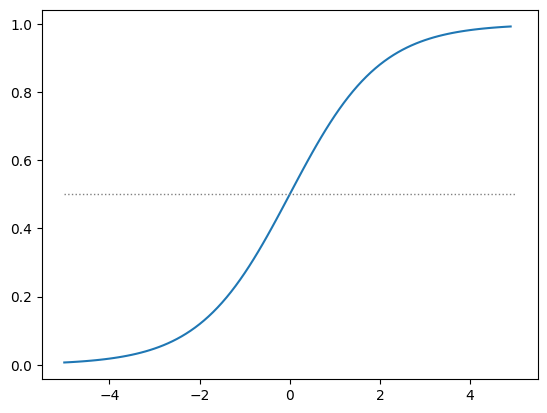

In [ ]:
import torch
import matplotlib.pyplot as plot

x = torch.arange(-5., 5., 0.1)
y = torch.sigmoid(x)
plot.plot(x.numpy(), y.numpy())
plot.plot([-5, 5], [0.5, 0.5], color='gray', linewidth=1, linestyle='dotted')
plot.show()

**Tanh** (hyperbolic tangent, variant of the sigmoid)

$f(x) = tanh(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}$

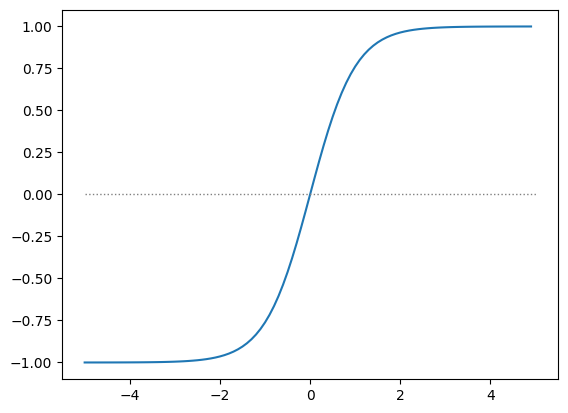

In [ ]:
import torch
import matplotlib.pyplot as plot

x = torch.arange(-5., 5., 0.1)
y = torch.tanh(x)
plot.plot(x.numpy(), y.numpy())
plot.plot([-5, 5], [0.0, 0.0], color='gray', linewidth=1, linestyle='dotted')
plot.show()

**ReLU** (rectified linear unit)

$f(x) = max(0, x)$

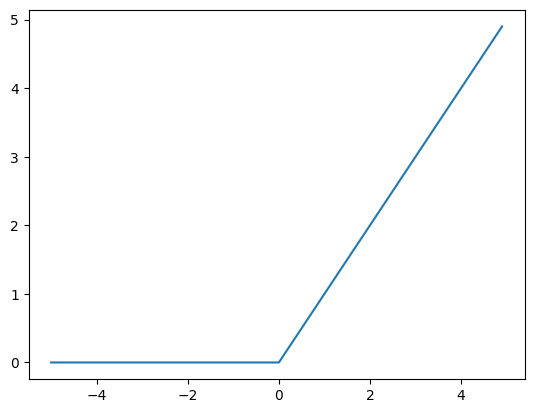

In [ ]:
x = torch.arange(-5., 5., 0.1)
y = torch.relu(x)
plot.plot(x.numpy(), y.numpy())
plot.show()

#### Loss functions

**Mean Squared Error (MSE) Loss**

Used for regression problems where the produced output and the expected output are numerical values

$L(y, \hat{y}) = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y_i})^2$

In [ ]:
import torch
import torch.nn as nn

mse_loss = nn.MSELoss()
produced = torch.randn(2, 4, requires_grad=True)
print(produced)
expected = torch.randn(2, 4)
print(expected)
loss = mse_loss(produced, expected)
print(loss)

tensor([[-0.5718, -1.0057,  1.4750, -1.2211],
        [-0.6612,  1.1907, -1.7957,  0.0801]], requires_grad=True)
tensor([[ 0.9570, -0.9523,  1.6849,  0.7815],
        [ 0.8585,  0.8991, -0.5685, -1.7838]])
tensor(1.7212, grad_fn=<MseLossBackward0>)


**Categorical Cross-Entropy Loss**

Used for multiclass problems where the produced output and the expected output are vectors over the classes (categories) for the given input.

$L(y, \hat{y}) = -\sum_{i=1}^n y_i log(\hat{y_i})$

 If the correct output class is only one (say, 1 in position $j$ of vector $y$, 0 elsewhere), the cross-entropy loss reduces to:

$L(y, \hat{y}) = - log(\hat{y}_j)$

Note: the CrossEntropyLoss class in PyTorch computes both the cross entropy loss and log softmax:

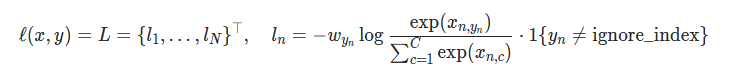


In [ ]:
import torch
import torch.nn as nn

# https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss
# Note that this case is equivalent to applying LogSoftmax on an input, followed by NLLLoss.
# Note that all these items are classes that have to be instantiated
# log = nn.LogSoftmax(dim=1)
#
ce_loss = nn.CrossEntropyLoss() # for binary classification, we can use nn.BCELoss()
# here we are providing two
produced = torch.randn(2, 4) # 2*4, normal distribution
print(produced)
# input is an index for each vector indicating the correct category/class
expected = torch.tensor([1, 0], dtype=torch.int64)
print(expected)
loss = ce_loss(produced, expected)
loss2 = nn.NLLLoss()(nn.LogSoftmax(dim=1)(produced), expected)
print(loss, loss2)

tensor([[-2.1217, -0.1556,  0.1774, -1.4122],
        [-0.2613, -0.4598, -0.5889,  1.3419]])
tensor([1, 0])
tensor(1.5264) tensor(1.5264)


## Language classification with the Perceptron

This task consists in classify the language of a given text.

Is a very straight forward task:



### Setup

Before actually doing something, let's `import` the modules we will need later.

In [ ]:
from random import randint

import torch
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
#import torch.nn.functional as F
# optimization algorithms
import torch.optim as optim

### Data Preparation

First, let's create a `LanguageRecognitionDataset` class for our training, validation, and test data.

In [ ]:
class LanguageRecognitionDataset(Dataset):
    """An automatically generated dataset for our language classification task."""

    def _get_bigrams(self, sentence_list):
      bigrams = {}
      # for each sentence
      for s in sentence_list: # maybe limit
        # for each bigram
        for k in range(len(s)-1):
          bigrams[s[k:k+2]] = 1.0
      return bigrams.keys()

    def _get_bigram_vector(self, sentence):
      sent_bigrams = self._get_bigrams([sentence])
      vector = []

      # self.bigrams = {'th', 'he', 'e_', 'i_'}
      # sent_bigrams = {'th', 'he'}

      for bigram in self.bigrams:
        # something like: vector.append(sent_bigrams.contains(bigram) ? 1.0 : 0.0)
        vector.append(1.0 if bigram in sent_bigrams else 0.0)

      # vector = [1.0, 1.0, 0.0, 0.0]
      return vector

    def __init__(self, sample, training_bigrams = None):
        """
        Args:
            sample: List of sentences with their classification (True/False)
        """

        self.num_samples = len(sample)
        if not training_bigrams:
          self.bigrams = self._get_bigrams([x for x, _ in sample])
        else:
          self.bigrams = training_bigrams

        # training data is a list of dictionaries
        # each dictionary contains two keys: 'inputs' and 'outputs'
        self.data = []
        for sentence, gold_label in sample:
            sentence = sentence.lower()
            item = {'inputs': torch.tensor(self._get_bigram_vector(sentence)), 'outputs': torch.tensor([gold_label])}
            self.data.append(item)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, i):
        return self.data[i]

LanguageRecognitionDataset([("ciao ciao pippo", 1), ("la casa si trova in collina", 1)])[1]

{'inputs': tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'outputs': tensor([1])}

The above dataset class can be easily used to automatically generate data for our task.

Let's create a simple dataset instance for testing purposes.

In [ ]:
training_sentences = [("Scienziata italiana scopre la più grande esplosione nell’Universo.", 1.0),
                      ("Nell’ammasso di galassie di Ofiuco, distante 390 milioni di anni luce.", 1.0),
                      ("Ha rilasciato una quantità di energia 5 volte più grande della precedente che deteneva il primato.", 1.0),
                      ("Syria war: Turkey says thousands of migrants have crossed to EU.", 0.0),
                      ("Turkey could no longer deal with the amount of people fleeing Syria's civil war, he added.", 0.0),
                      ("Greece says it has blocked thousands of migrants from entering illegally from Turkey.", 0.0),
                      ("Tutto perfetto? Non proprio. Ci sono elementi problematici che vanno considerati.", 1.0),
                      ("Il primo è l’autonomia degli studenti, che devono essere in grado di gestire la tecnologia.", 1.0),
                      ("Il secondo, è la durata e la cadenza delle lezioni.", 1.0),
                      ("Per motivi di connessione, di competenze, di strumenti.", 1.0),
                      ("Serve un’assistenza dedicata.", 1.0),
                      ("Potremmo completare l’anno scolastico in versione virtuale?", 1.0),
                      ("Siamo preparati per affiancare la didattica tradizionale a quella virtuale, ma non siamo pronti per sostituirla", 1.0),
                      ("Various architectures of recurrent neural networks have been successful.", 0.0),
                      ("They perform tasks relating to sequence measuring", 0.0),
                      ("The networks operate by processing input components sequentially", 0.0),
                      ("They retain a hidden vector between iterations", 0.0),
                      ("It is constantly used and modified throughout the sequence.", 0.0),
                      ("They are able to model arbitrarily complicated programs.", 0.0),
                      ("L’Istituto, che raccoglie studenti di liceo scientifico, linguistico e tecnico economico, è l’esempio ideale.", 1.0),
                      ]

validation_sentences = [("L’Istituto superiore di sanità ha confermato tutti i casi esaminati.", 1.0),
                        ("Measures announced after an emergency cabinet meeting also include the cancellation of the Paris half-marathon which was to be held on Sunday.", 0.0),
                        ("Lavagne in condivisione, documenti scaricabili sulla piattaforma gratuita, esercizi collaborativi.", 1.0),
                        ("Each encoder consists of two major components", 0.0),
                        ]



test_sentences = [("Il ministro della Salute francese ha raccomandato di salutarsi mantenendo le distanze, mentre l’Organizzazione mondiale della sanità alza l’allerta a molto alta.", 1.0),
                  ("Possiamo riammalarci ma in questo caso si parla di ricaduta.", 1.0),
                  ("The vast majority of infections and deaths are in China, where the virus originated late last year.", 0.0),
                  ("France has banned all indoor gatherings of more than 5,000 people, as part of efforts to contain the country's coronavirus outbreak", 0.0)]

def check_dataset_class():
    simple_dataset = LanguageRecognitionDataset(training_sentences)

    print('Dataset test:')
    for i in range(len(training_sentences)):
        print(f'  sample {i}: {simple_dataset[i]}')

check_dataset_class()

Dataset test:
  sample 0: {'inputs': tensor([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

### Model Training

Before training our model, we need to define how we are going to train it.

The following `Trainer` class defines the following main ingredients for model training:

*   A **training loop** that iterates over a set of training examples that are used by the model to learn to solve our task.
*   An **evaluation function** to evaluate the learning progress of our model.
*   A **prediction function** to actually obtain the output of the (possibily trained) model.

In order to correctly learn, our model needs a *loss function* to determine how far the output of our model is from what it should have been, and an *optimizer* to "correct" the model internal weights based on the value of the loss function.



In [ ]:
import statistics

class Trainer():
    """Utility class to train and evaluate a model."""

    def __init__(
        self,
        model,
        loss_function,
        optimizer,
        binary):
        """
        Args:
            model: the model we want to train.
            loss_function: the loss_function to minimize.
            optimizer: the optimizer used to minimize the loss_function.
        """
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.binary = binary

    def _compute_accuracy_binary(self, predictions, labels):
        discrete_predictions = predictions.detach().clone()
        discrete_predictions.apply_(lambda x: 1 if x > 0.5 else 0)

        return torch.mean(torch.Tensor([1 if p==l else 0 for p, l in list(zip(discrete_predictions.view(-1), labels.view(-1)))])).item() # item works with single element tensor

    def _compute_accuracy_multiclass(self, predictions, labels):
        discrete_predictions = predictions.detach().clone()
        discrete_predictions = discrete_predictions.argmax(dim=1)

        return torch.mean(torch.Tensor([1 if p==l else 0 for p, l in list(zip(discrete_predictions.view(-1), labels.view(-1)))])).item() # item works with single element tensor

    def _compute_accuracy(self, predictions, labels):
        if self.binary:
          return self._compute_accuracy_binary(predictions, labels)
        else:
          return self._compute_accuracy_multiclass(predictions, labels)

    def train(self, train_dataset, valid_dataset, epochs=1):
        """
        Args:
            train_dataset: a Dataset or DatasetLoader instance containing
                the training instances.
            valid_dataset: a Dataset or DatasetLoader instance used to evaluate
                learning progress.
            epochs: the number of times to iterate over train_dataset.

        Returns:
            avg_train_loss: the average training loss on train_dataset over
                epochs.
        """
        assert epochs > 1 and isinstance(epochs, int)
        print('Training...')

        train_loss = []
        train_accuracy = []
        valid_loss = []
        valid_accuracy = []

        for epoch in range(epochs):
            print(' Epoch {:03d}'.format(epoch + 1))

            epoch_loss = 0.0
            epoch_accuracy = 0.0

            for step, sample in enumerate(train_dataset):
                inputs = sample['inputs'] # B x N: B=batch size and N=vocabulary size
                labels = sample['outputs'] # B x 1

                # we need to set the gradients to zero before starting to do backpropragation
                # because PyTorch accumulates the gradients on subsequent backward passes
                self.optimizer.zero_grad()

                predictions = self.model(inputs)

                if not self.binary:
                  labels = labels.view(-1).long()

                sample_loss = self.loss_function(predictions, labels)

                #print("Before BP:", list(model.parameters()))

                sample_loss.backward()
                self.optimizer.step()

                #print("After BP:", list(model.parameters()))

                # sample_loss is a Tensor, tolist returns a float (alternative: use .float() instead of .tolist())
                epoch_loss += sample_loss.tolist()

                print('    [E: {:2d} @ step {}] current avg loss = {:0.4f}'.format(epoch, step, epoch_loss / (step + 1)))

                epoch_accuracy += self._compute_accuracy(predictions, labels)

            avg_epoch_loss = epoch_loss / len(train_dataset)
            avg_epoch_accuracy = epoch_accuracy / len(train_dataset)

            print('  [E: {:2d}] train loss = {:0.4f} | train accuracy = {:0.4f}'.format(epoch, avg_epoch_loss, avg_epoch_accuracy))

            valid_loss_epoch, valid_accuracy_epoch = self.evaluate(valid_dataset)

            print('  [E: {:2d}] valid loss = {:0.4f} | eval accuracy =. {:0.4f}'.format(epoch, valid_loss_epoch, valid_accuracy_epoch))

            train_loss.append(avg_epoch_loss)
            train_accuracy.append(avg_epoch_accuracy)
            valid_loss.append(valid_loss_epoch)
            valid_accuracy.append(valid_accuracy_epoch)

        print('... Done!')

        avg_epoch_loss = statistics.mean(train_loss)
        avg_epoch_accuracy = statistics.mean(train_accuracy)
        return {
            "avg_epoch_loss": avg_epoch_loss,
            "avg_epoch_accuracy": avg_epoch_accuracy,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "valid_loss": valid_loss,
            "valid_accuracy": valid_accuracy
            }


    def evaluate(self, valid_dataset):
        """
        Args:
            valid_dataset: the dataset to use to evaluate the model.

        Returns:
            avg_valid_loss: the average validation loss over valid_dataset.
            avg_valid_accuracy: the average validation accuracy over valid_dataset.
        """
        valid_loss = 0.0
        validation_accuracy = 0.0

        # no gradient updates here, we are at inference time!
        with torch.no_grad():
            for sample in valid_dataset:
                inputs = sample['inputs']
                labels = sample['outputs']

                predictions = self.model(inputs)

                if not self.binary:
                  labels = labels.view(-1).long()

                sample_loss = self.loss_function(predictions, labels)
                valid_loss += sample_loss.tolist()

                validation_accuracy += self._compute_accuracy(predictions, labels)

        return valid_loss / len(valid_dataset), validation_accuracy / len(valid_dataset)


    def predict(self, x):
        """
        Returns: hopefully the right prediction.
        """
        return self.model(x).tolist()

The last things to do are, defining our datasets...

In [ ]:
training_dataset = DataLoader(LanguageRecognitionDataset(training_sentences), batch_size=6)
validation_dataset = DataLoader(LanguageRecognitionDataset(validation_sentences, training_dataset.dataset.bigrams), batch_size=2)
test_dataset = DataLoader(LanguageRecognitionDataset(test_sentences, training_dataset.dataset.bigrams), batch_size=2)

... setup a trainer, and ...

In [ ]:
print("Number of input dimensions", len(training_dataset.dataset.bigrams))
model = Perceptron(len(training_dataset.dataset.bigrams))
trainer = Trainer(
    model,
    loss_function = nn.BCELoss(),
    optimizer = optim.SGD(model.parameters(), lr=0.1),
    binary=True
)

Number of input dimensions 307


... train our model.

In [ ]:
history = trainer.train(training_dataset, validation_dataset,
              epochs=10)

Training...
 Epoch 001
    [E:  0 @ step 0] current avg loss = 0.7564
    [E:  0 @ step 1] current avg loss = 0.7056
    [E:  0 @ step 2] current avg loss = 0.7536
    [E:  0 @ step 3] current avg loss = 0.7168
  [E:  0] train loss = 0.7168 | train accuracy = 0.5833
  [E:  0] valid loss = 0.4525 | eval accuracy =. 0.7500
 Epoch 002
    [E:  1 @ step 0] current avg loss = 0.3406
    [E:  1 @ step 1] current avg loss = 0.3489
    [E:  1 @ step 2] current avg loss = 0.4032
    [E:  1 @ step 3] current avg loss = 0.3646
  [E:  1] train loss = 0.3646 | train accuracy = 0.9583
  [E:  1] valid loss = 0.3696 | eval accuracy =. 1.0000
 Epoch 003
    [E:  2 @ step 0] current avg loss = 0.2080
    [E:  2 @ step 1] current avg loss = 0.2394
    [E:  2 @ step 2] current avg loss = 0.2716
    [E:  2 @ step 3] current avg loss = 0.2423
  [E:  2] train loss = 0.2423 | train accuracy = 1.0000
  [E:  2] valid loss = 0.3267 | eval accuracy =. 1.0000
 Epoch 004
    [E:  3 @ step 0] current avg loss = 0.14

Let's take a look the behaviour of the model during the training

In [ ]:
print("### Summary")
print("average loss", history["avg_epoch_loss"])
print("average accuracy", history["avg_epoch_accuracy"])

### Summary
average loss 0.21062012976035477
average accuracy 0.9541666660457849


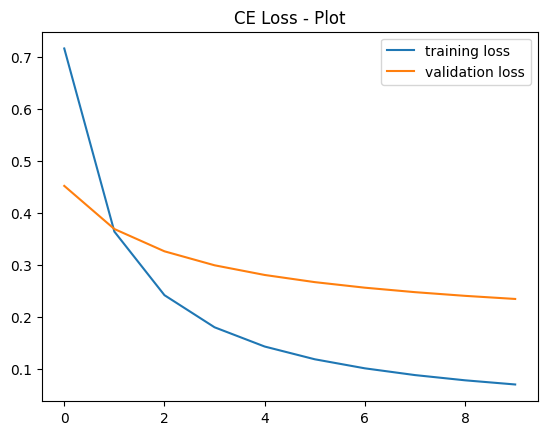

In [ ]:
import matplotlib.pyplot as plt

plt.title("CE Loss - Plot")
plt.plot(history["train_loss"], label="training loss")
plt.plot(history["valid_loss"], label="validation loss")
plt.legend()

plt.show()

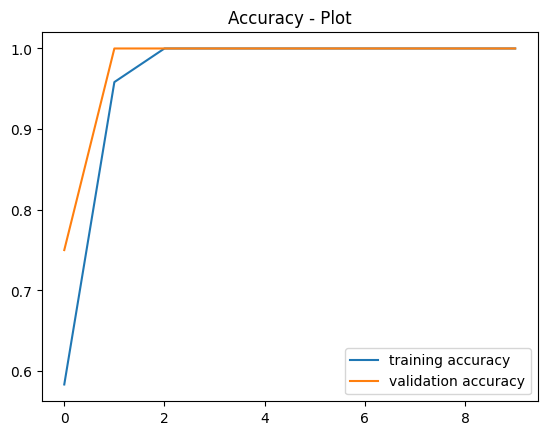

In [ ]:
plt.title("Accuracy - Plot")
plt.plot(history["train_accuracy"], label="training accuracy")
plt.plot(history["valid_accuracy"], label="validation accuracy")
plt.legend()

plt.show()

### Model Evaluation

Let's see if our model has actually learnt something.

Indeed, the loss seems to be consistent.

In [ ]:
trainer.evaluate(test_dataset)

(0.1450057476758957, 1.0)

And our model seems to give accurate predictions (the first two test sentences were in Italian, the other two in English).

In [ ]:
for step, batch in enumerate(test_dataset):
  print('step=', step, 'predictions=', trainer.predict(batch['inputs']), 'ground truth=', batch['outputs'])

step= 0 predictions= [[0.9612644910812378], [0.8392063975334167]] ground truth= tensor([[1.],
        [1.]])
step= 1 predictions= [[0.2153235226869583], [0.11550191044807434]] ground truth= tensor([[0.],
        [0.]])


## Language classification with a Feedforward Neural Network

A step-by-step neural network for a simple task.

### Task Definition

Let's build a feedforward neural network that performs language classification.

### Model Definition

Now, we are ready to define our neural network.

For the sake of simplicity, we will define a neural network with a single hidden layer.

Feel free to update the model!

In [ ]:
class LanguageRecognitionFF(nn.Module):
    """A simple model that classifies language"""

    def __init__(self, input_dim, hparams):
        super().__init__()

        # Hidden layer: transforms the input value/scalar into
        # a hidden vector representation.
        self.fc1 = nn.Linear(input_dim, hparams.hidden_size)

        self.relu = nn.ReLU()

        # Output layer: transforms the hidden vector representation
        # into a value/scalar (hopefully the input value + 1).
        self.fc2 = nn.Linear(hparams.hidden_size, 1)

        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        hidden = self.fc1(x)
        relu = self.relu(hidden)
        result = self.fc2(relu)
        return self.sigmoid(result)

### Model Building

It's always a good idea to keep the hyperparameters separate from the model definition.
In this way, we can easily experiment with different hyperparameter values without touching our neural network definition.

In [ ]:
class HParams():
    hidden_size = 8

Finally, we instantiate our neural network.

In [ ]:
model_ff = LanguageRecognitionFF(len(training_dataset.dataset.bigrams), HParams)

### Model Training

We now set up a training much like with the single perceptron model:

In [ ]:
trainer = Trainer(
    model = model_ff,
    loss_function = nn.MSELoss(),
    optimizer = optim.SGD(model_ff.parameters(), lr=0.05), #lr=1e-5)
    binary=True
)

... and train our model.

In [ ]:
history = trainer.train(training_dataset, validation_dataset, 200)

Training...
 Epoch 001
    [E:  0 @ step 0] current avg loss = 0.2337
    [E:  0 @ step 1] current avg loss = 0.2205
    [E:  0 @ step 2] current avg loss = 0.2457
    [E:  0 @ step 3] current avg loss = 0.2465
  [E:  0] train loss = 0.2465 | train accuracy = 0.5833
  [E:  0] valid loss = 0.2526 | eval accuracy =. 0.5000
 Epoch 002
    [E:  1 @ step 0] current avg loss = 0.2229
    [E:  1 @ step 1] current avg loss = 0.2129
    [E:  1 @ step 2] current avg loss = 0.2375
    [E:  1 @ step 3] current avg loss = 0.2353
  [E:  1] train loss = 0.2353 | train accuracy = 0.5833
  [E:  1] valid loss = 0.2490 | eval accuracy =. 0.5000
 Epoch 003
    [E:  2 @ step 0] current avg loss = 0.2122
    [E:  2 @ step 1] current avg loss = 0.2056
    [E:  2 @ step 2] current avg loss = 0.2291
    [E:  2 @ step 3] current avg loss = 0.2247
  [E:  2] train loss = 0.2247 | train accuracy = 0.6250
  [E:  2] valid loss = 0.2457 | eval accuracy =. 0.5000
 Epoch 004
    [E:  3 @ step 0] current avg loss = 0.20

In [ ]:
print("### Summary")
print("average loss", history["avg_epoch_loss"])
print("average accuracy", history["avg_epoch_accuracy"])

### Summary
average loss 0.02059155578535865
average accuracy 0.9904166666790843


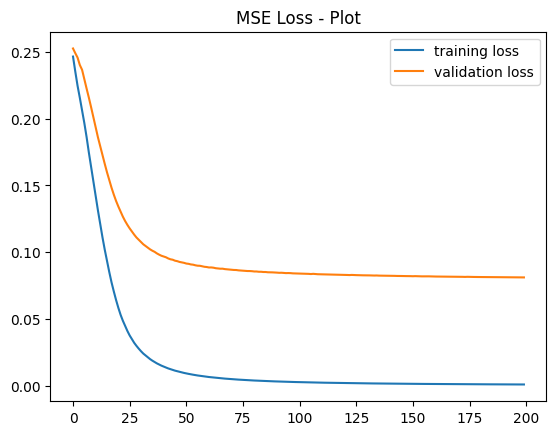

In [ ]:
import matplotlib.pyplot as plt

plt.title("MSE Loss - Plot")
plt.plot(history["train_loss"], label="training loss")
plt.plot(history["valid_loss"], label="validation loss")
plt.legend()

plt.show()

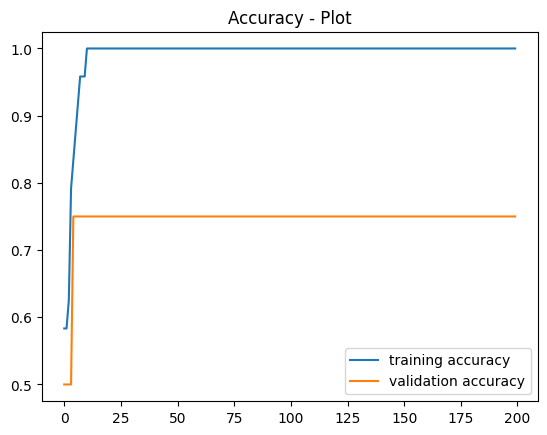

In [ ]:
import matplotlib.pyplot as plt

plt.title("Accuracy - Plot")
plt.plot(history["train_accuracy"], label="training accuracy")
plt.plot(history["valid_accuracy"], label="validation accuracy")
plt.legend()

plt.show()

### Model Evaluation

Let's see if our model has actually learnt something.

Indeed, the loss seems to be quite low on our test dataset.

In [ ]:
trainer.evaluate(test_dataset)

(0.022524012252688408, 1.0)

And our model seems to give accurate predictions.

In [ ]:
for step, batch in enumerate(test_dataset):
  print(trainer.predict(batch['inputs']), batch['outputs'])

[[0.9706563353538513], [0.9125085473060608]] tensor([[1.],
        [1.]])
[[0.2771211564540863], [0.06916723400354385]] tensor([[0.],
        [0.]])


# Multi-class classification



In [ ]:
training_sentences = [
                      ("Scienziata italiana scopre la più grande esplosione nell’Universo.", 1.0),
                      ("Nell’ammasso di galassie di Ofiuco, distante 390 milioni di anni luce.", 1.0),
                      ("Ha rilasciato una quantità di energia 5 volte più grande della precedente che deteneva il primato.", 1.0),
                      ("Syria war: Turkey says thousands of migrants have crossed to EU.", 0.0),
                      ("Turkey could no longer deal with the amount of people fleeing Syria's civil war, he added.", 0.0),
                      ("Greece says it has blocked thousands of migrants from entering illegally from Turkey.", 0.0),
                      ("Tutto perfetto? Non proprio. Ci sono elementi problematici che vanno considerati.", 1.0),
                      ("Il primo è l’autonomia degli studenti, che devono essere in grado di gestire la tecnologia.", 1.0),
                      ("Il secondo, è la durata e la cadenza delle lezioni.", 1.0),
                      ("Per motivi di connessione, di competenze, di strumenti.", 1.0),
                      ("Serve un’assistenza dedicata.", 1.0),
                      ("Potremmo completare l’anno scolastico in versione virtuale?", 1.0),
                      ("Siamo preparati per affiancare la didattica tradizionale a quella virtuale, ma non siamo pronti per sostituirla", 1.0),
                      ("Various architectures of recurrent neural networks have been successful.", 0.0),
                      ("They perform tasks relating to sequence measuring", 0.0),
                      ("The networks operate by processing input components sequentially", 0.0),
                      ("They retain a hidden vector between iterations", 0.0),
                      ("It is constantly used and modified throughout the sequence.", 0.0),
                      ("They are able to model arbitrarily complicated programs.", 0.0),
                      ("L’Istituto, che raccoglie studenti di liceo scientifico, linguistico e tecnico economico, è l’esempio ideale.", 1.0),
                      ("Obtuvo su doctorado en Filología Germánica en la Universidad de Heidelberg en 1921, algo que expresó muchas veces en su diario personal.", 2.0),
                      ("Pronunció un elocuente discurso sobre la guerra total en el Palacio de los Deportes de Berlín.", 2.0),
                      ("Sneakin' Sally Through the Alley es el álbum debut del cantante británico de rock Robert Palmer, publicado en 1974 por Island Records.", 2.0),
                      ("Registrado en tres estudios y con la producción de Steve Smith.", 2.0),
                      ("El conde-duque de Olivares a caballo, también conocido como Retrato ecuestre del conde-duque de Olivares.", 2.0),
                      ("Se expone en el Museo del Prado, Madrid.", 2.0),
                      ("Se sometió a un entrenamiento vocal durante algunos años antes de lanzar su primer álbum solista Like a Movie en 2002.", 2.0),
                      ("El programa dio oportunidades a nuevos cantantes para mostrarse ante el público, una nueva plataforma para generar más seguidores.", 2.0),
                      ("En 2011, fue transferido a la agencia YCM Entertainment.", 2.0),
                      ]

validation_sentences = [
                        ("L’Istituto superiore di sanità ha confermato tutti i casi esaminati.", 1.0),
                        ("Measures announced after an emergency cabinet meeting also include the cancellation of the Paris half-marathon which was to be held on Sunday.", 0.0),
                        ("Lavagne in condivisione, documenti scaricabili sulla piattaforma gratuita, esercizi collaborativi.", 1.0),
                        ("Each encoder consists of two major components", 0.0),
                        ("Poco después de ingresar, reclutó a la cantante Ailee.", 2.0),
                        ("En mayo de 2014, se informó que Wheesung regresaría a la industria musical luego de dos años y siete meses de ausencia.", 2.0),
                        ]



test_sentences = [
                  ("Il ministro della Salute francese ha raccomandato di salutarsi mantenendo le distanze, mentre l’Organizzazione mondiale della sanità alza l’allerta a molto alta.", 1.0),
                  ("Possiamo riammalarci ma in questo caso si parla di ricaduta.", 1.0),
                  ("The vast majority of infections and deaths are in China, where the virus originated late last year.", 0.0),
                  ("France has banned all indoor gatherings of more than 5,000 people, as part of efforts to contain the country's coronavirus outbreak.", 0.0),
                  ("Autoridades creen que ya tenía tiempo de fallecido al descubrir su cuerpo.", 2.0),
                  ("Estos bloques silábicos pueden ser escritos tanto horizontalmente, de izquierda a derecha, como verticalmente, de arriba hacia abajo.", 2.0),
                  ]

def check_dataset_class():
    simple_dataset = LanguageRecognitionDataset(training_sentences)

    print('Dataset test:')
    for i in range(len(training_sentences)):
        print(f'  sample {i}: {simple_dataset[i]}')

check_dataset_class()

Dataset test:
  sample 0: {'inputs': tensor([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

In [ ]:
# nn.Module is the base class for all neural network modules
class PerceptronMultiClass(nn.Module):
    """Our perceptron class"""

    def __init__(self, input_dim):
        """
        Constructor
        Args: input_dim (int): size of the input features
        """
        super().__init__()
        self.fc = nn.Linear(input_dim, 3)

    def forward(self, x_in):
        # squeeze unwraps the result from the singleton list
        return self.fc(x_in) #.squeeze()

In [ ]:
print(PerceptronMultiClass(10).forward(torch.ones(10)))

tensor([0.1635, 0.1764, 0.9308], grad_fn=<ViewBackward0>)


In [ ]:
class LanguageRecognitionFFMultiClass(nn.Module):
    """A simple model that classifies language"""

    def __init__(self, input_dim, hparams):
        super().__init__()

        # Hidden layer: transforms the input value/scalar into
        # a hidden vector representation.
        self.fc1 = nn.Linear(input_dim, hparams.hidden_size)

        self.relu = nn.ReLU()

        # Output layer: transforms the hidden vector representation
        # into a value/scalar (hopefully the input value + 1).
        self.fc2 = nn.Linear(hparams.hidden_size, 3)

    def forward(self, x):
        hidden = self.fc1(x)
        relu = self.relu(hidden)
        result = self.fc2(relu)
        return result

In [ ]:
training_dataset = DataLoader(LanguageRecognitionDataset(training_sentences), batch_size=6, shuffle=True)
validation_dataset = DataLoader(LanguageRecognitionDataset(validation_sentences, training_dataset.dataset.bigrams), batch_size=2, shuffle=True)
test_dataset = DataLoader(LanguageRecognitionDataset(test_sentences, training_dataset.dataset.bigrams), batch_size=2, shuffle=True)

In [ ]:
print("Number of input dimensions", len(training_dataset.dataset.bigrams))
model = PerceptronMultiClass(len(training_dataset.dataset.bigrams))
trainer = Trainer(
    model,
    loss_function = nn.CrossEntropyLoss(),
    optimizer = optim.SGD(model.parameters(), lr=0.2),
    binary=False
)

Number of input dimensions 416


In [ ]:
history = trainer.train(training_dataset, validation_dataset, 10)

Training...
 Epoch 001
    [E:  0 @ step 0] current avg loss = 1.1224
    [E:  0 @ step 1] current avg loss = 1.0245
    [E:  0 @ step 2] current avg loss = 1.0241
    [E:  0 @ step 3] current avg loss = 0.9278
    [E:  0 @ step 4] current avg loss = 0.8872
  [E:  0] train loss = 0.8872 | train accuracy = 0.7000
  [E:  0] valid loss = 0.7746 | eval accuracy =. 0.6667
 Epoch 002
    [E:  1 @ step 0] current avg loss = 0.4839
    [E:  1 @ step 1] current avg loss = 0.3678
    [E:  1 @ step 2] current avg loss = 0.3759
    [E:  1 @ step 3] current avg loss = 0.3597
    [E:  1 @ step 4] current avg loss = 0.3323
  [E:  1] train loss = 0.3323 | train accuracy = 0.9667
  [E:  1] valid loss = 0.4919 | eval accuracy =. 0.8333
 Epoch 003
    [E:  2 @ step 0] current avg loss = 0.1713
    [E:  2 @ step 1] current avg loss = 0.1686
    [E:  2 @ step 2] current avg loss = 0.1468
    [E:  2 @ step 3] current avg loss = 0.1515
    [E:  2 @ step 4] current avg loss = 0.1462
  [E:  2] train loss = 0.1

In [ ]:
for step, batch in enumerate(test_dataset):
  print('step=', step, 'predictions=', trainer.predict(batch['inputs']), 'ground truth=', batch['outputs'])

step= 0 predictions= [[1.2063356637954712, -0.17320336401462555, -1.3304824829101562], [-1.5643649101257324, 1.399375319480896, 0.03581401705741882]] ground truth= tensor([[0.],
        [1.]])
step= 1 predictions= [[-1.9037375450134277, 2.6860930919647217, -1.065367341041565], [1.952007532119751, -1.0211527347564697, -0.8469759225845337]] ground truth= tensor([[1.],
        [0.]])
step= 2 predictions= [[-0.8234047889709473, -0.6711193919181824, 1.1826341152191162], [-0.38620442152023315, 0.4594070315361023, 0.06539231538772583]] ground truth= tensor([[2.],
        [2.]])


In [ ]:
print("### Summary")
print("average loss", history["avg_epoch_loss"])
print("average accuracy", history["avg_epoch_accuracy"])

### Summary
average loss 0.1767587349563837
average accuracy 0.9666666668653489


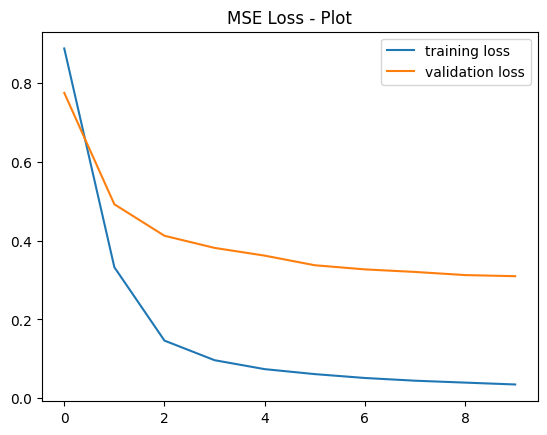

In [ ]:
import matplotlib.pyplot as plt

plt.title("MSE Loss - Plot")
plt.plot(history["train_loss"], label="training loss")
plt.plot(history["valid_loss"], label="validation loss")
plt.legend()

plt.show()

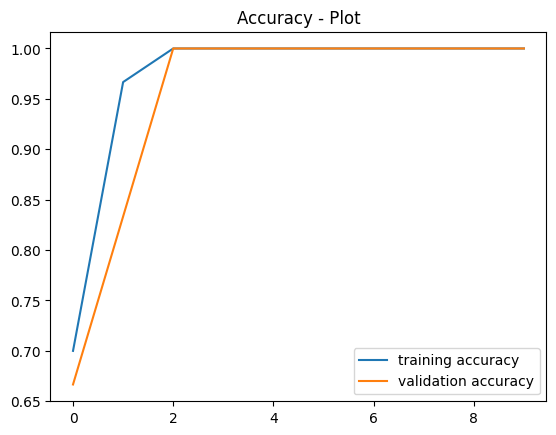

In [ ]:
plt.title("Accuracy - Plot")
plt.plot(history["train_accuracy"], label="training accuracy")
plt.plot(history["valid_accuracy"], label="validation accuracy")
plt.legend()

plt.show()

In [ ]:
model.fc.weight[0] # english
model.fc.weight[1] # italian
model.fc.weight[2] # spanish

model.fc.weight[0].topk(5).indices.tolist()

[141, 134, 135, 11, 157]

In [ ]:
print("TOP 10 element representative for English Language")
print([list(training_dataset.dataset.bigrams)[i] for i in model.fc.weight[0].topk(10).indices])

print("TOP 10 element representative for Italian Language")
print([list(training_dataset.dataset.bigrams)[i] for i in model.fc.weight[1].topk(10).indices])

print("TOP 10 element representative for Spanish Language")
print([list(training_dataset.dataset.bigrams)[i] for i in model.fc.weight[2].topk(10).indices])

TOP 10 element representative for English Language
['th', 'ey', 'y ', 'it', 'd ', 'ee', 'rk', 't ', 'ou', 'ce']
TOP 10 element representative for Italian Language
['i ', 'si', 'ti', 'nn', 'zi', 'nz', 'l’', 'st', 'è ', 'll']
TOP 10 element representative for Spanish Language
['do', 'n ', ' e', 's ', 'o ', 'lb', 'id', 'oc', ' d', 'ex']


## BONUS TRACK Sentiment Analysis


Here we will get the dataset from [huggingface](https://huggingface.co/datasets) repository.


- https://huggingface.co/datasets/stanfordnlp/sst2/viewer/default/validation?row=0&views%5B%5D=validation


Huggingface is an "open-source" company that offer a suite of tools to deal with NLP models and dataset.


- Online space to store Models and Datasets
- python libraries to train models and handle datasets
- huge community
- a "well" done documentation

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

sentiment_analysis_ds = load_dataset("stanfordnlp/sst2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [ ]:
sentiment_analysis_ds

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

In [ ]:
# subsample train and validation, 1000 and 100

sentiment_analysis_ds_tr = sentiment_analysis_ds["train"].select(range(5000))
sentiment_analysis_ds_vl = sentiment_analysis_ds["validation"].select(range(100))
sentiment_analysis_ds_ts = sentiment_analysis_ds["validation"].select(range(100, 200))

In [ ]:
# check label balancing

import collections

print(f"train label distribution: {collections.Counter(sentiment_analysis_ds_tr['label'])}")

print(f"validation label distribution: {collections.Counter(sentiment_analysis_ds_vl['label'])}")

print(f"test label distribution: {collections.Counter(sentiment_analysis_ds_ts['label'])}")

train label distribution: Counter({1: 2758, 0: 2242})
validation label distribution: Counter({1: 52, 0: 48})
test label distribution: Counter({0: 53, 1: 47})


In [ ]:
class SADataset(Dataset):
    """An automatically generated dataset for our language classification task."""

    def _get_bigrams(self, sentence_list):
      bigrams = {}
      # for each sentence
      for s in sentence_list: # maybe limit
        # for each bigram

        if len(list(bigrams.keys())) > self.vocab_max_len:
          return list(bigrams.keys())[:self.vocab_max_len]

        for k in range(len(s)-1):
          if len(s[k:k+30]) < 30:
            break
          bigrams[s[k:k+20]] = 1.0
      return list(bigrams.keys())

    def _get_bigram_vector(self, sentence):
      sent_bigrams = self._get_bigrams([sentence])
      vector = []

      # self.bigrams = {'th', 'he', 'e_', 'i_'}
      # sent_bigrams = {'th', 'he'}

      for bigram in self.bigrams:
        # something like: vector.append(sent_bigrams.contains(bigram) ? 1.0 : 0.0)
        vector.append(1.0 if bigram in sent_bigrams else 0.0)

      # vector = [1.0, 1.0, 0.0, 0.0]
      return vector

    def __init__(self, dataset, vocab_max_len = -1, training_bigrams = None):
        """
        Args:
            dataset: huggingface datset, with idx, sentence, label features
        """

        self.vocab_max_len = vocab_max_len

        self.num_samples = len(dataset)
        if not training_bigrams:
          self.bigrams = self._get_bigrams([x["sentence"] for x in dataset])
        else:
          self.bigrams = training_bigrams

        # training data is a list of dictionaries
        # each dictionary contains two keys: 'inputs' and 'outputs'
        self.data = []
        for sample in dataset:
            sentence = sample["sentence"].lower()
            item = {'inputs': torch.tensor(self._get_bigram_vector(sentence)), 'outputs': torch.tensor([sample["label"]], dtype=torch.float)}
            self.data.append(item)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, i):
        return self.data[i]

In [ ]:
training_dataset = DataLoader(SADataset(sentiment_analysis_ds_tr, vocab_max_len=2000), batch_size=18, shuffle=True)
validation_dataset = DataLoader(SADataset(sentiment_analysis_ds_vl, training_bigrams=training_dataset.dataset.bigrams), batch_size=2, shuffle=True)
test_dataset = DataLoader(SADataset(sentiment_analysis_ds_ts, training_bigrams=training_dataset.dataset.bigrams), batch_size=2, shuffle=True)

In [ ]:
print("Number of input dimensions", len(training_dataset.dataset.bigrams))
model = Perceptron(len(training_dataset.dataset.bigrams))
trainer = Trainer(
    model,
    loss_function = nn.MSELoss(),
    optimizer = optim.SGD(model.parameters(), lr=0.005),
    binary=True
)

Number of input dimensions 2000


In [ ]:
history = trainer.train(training_dataset, validation_dataset, 100)

Output streaming troncato alle ultime 5000 righe.
    [E: 82 @ step 58] current avg loss = 0.2490
    [E: 82 @ step 59] current avg loss = 0.2488
    [E: 82 @ step 60] current avg loss = 0.2487
    [E: 82 @ step 61] current avg loss = 0.2488
    [E: 82 @ step 62] current avg loss = 0.2488
    [E: 82 @ step 63] current avg loss = 0.2485
    [E: 82 @ step 64] current avg loss = 0.2486
    [E: 82 @ step 65] current avg loss = 0.2484
    [E: 82 @ step 66] current avg loss = 0.2485
    [E: 82 @ step 67] current avg loss = 0.2485
    [E: 82 @ step 68] current avg loss = 0.2485
    [E: 82 @ step 69] current avg loss = 0.2484
    [E: 82 @ step 70] current avg loss = 0.2484
    [E: 82 @ step 71] current avg loss = 0.2484
    [E: 82 @ step 72] current avg loss = 0.2484
    [E: 82 @ step 73] current avg loss = 0.2482
    [E: 82 @ step 74] current avg loss = 0.2479
    [E: 82 @ step 75] current avg loss = 0.2480
    [E: 82 @ step 76] current avg loss = 0.2480
    [E: 82 @ step 77] current avg loss

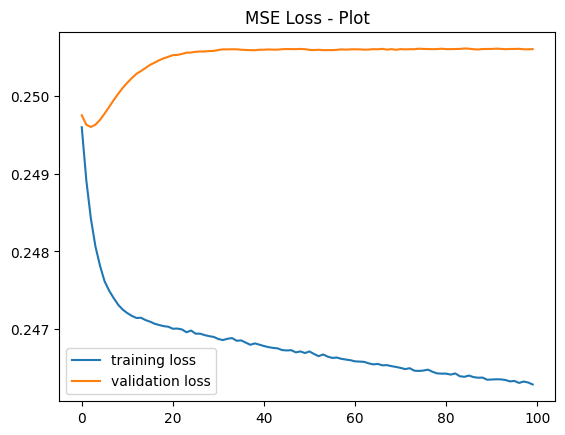

In [ ]:
import matplotlib.pyplot as plt

plt.title("MSE Loss - Plot")
plt.plot(history["train_loss"], label="training loss")
plt.plot(history["valid_loss"], label="validation loss")
plt.legend()

plt.show()

In [ ]:
model.fc.weight[0] # english

print([list(training_dataset.dataset.bigrams)[i] for i in model.fc.weight[0].topk(40).indices])

['ng a theme throughou', " best man '' clone b", ' a theme throughout ', 'quals the original a', " `` best man '' clon", 'weaving a theme thro', 'ritory with wit and ', 'e brave , uninhibite', 'eaving a theme throu', 'ith wit and original', 'iginal and in some w', 'mance in an admitted', 'ry with wit and orig', 'than another `` best', 'ginal and in some wa', 'eme throughout this ', 'oss swords with the ', "best man '' clone by", ' from the brave , un', " he has n't lost his", ' clone by weaving a ', 'originality , sugges', 'rave , uninhibited p', " n't lost his touch ", 'a theme throughout t', ' usual intelligence ', "in he has n't lost h", "ain he has n't lost ", 'more deeply thought ', 'ormance in an admitt', 'ual intelligence and', "'' clone by weaving ", 'ing off a superb per', ' off a superb perfor', 'ith bloody beauty as', 'nd originality , sug', 'oves once again he h', ' brave , uninhibited', "n't lost his touch ,", 'uty as vivid as any ']


In [ ]:
print("Number of input dimensions", len(training_dataset.dataset.bigrams))
model = LanguageRecognitionFF(len(training_dataset.dataset.bigrams), HParams)
trainer = Trainer(
    model,
    loss_function = nn.MSELoss(),
    optimizer = optim.SGD(model.parameters(), lr=0.1),
    binary=True
)

Number of input dimensions 2000


In [ ]:
history = trainer.train(training_dataset, validation_dataset, 50)

Output streaming troncato alle ultime 5000 righe.
    [E: 32 @ step 58] current avg loss = 0.2456
    [E: 32 @ step 59] current avg loss = 0.2454
    [E: 32 @ step 60] current avg loss = 0.2454
    [E: 32 @ step 61] current avg loss = 0.2455
    [E: 32 @ step 62] current avg loss = 0.2453
    [E: 32 @ step 63] current avg loss = 0.2451
    [E: 32 @ step 64] current avg loss = 0.2457
    [E: 32 @ step 65] current avg loss = 0.2458
    [E: 32 @ step 66] current avg loss = 0.2455
    [E: 32 @ step 67] current avg loss = 0.2454
    [E: 32 @ step 68] current avg loss = 0.2455
    [E: 32 @ step 69] current avg loss = 0.2456
    [E: 32 @ step 70] current avg loss = 0.2459
    [E: 32 @ step 71] current avg loss = 0.2461
    [E: 32 @ step 72] current avg loss = 0.2463
    [E: 32 @ step 73] current avg loss = 0.2465
    [E: 32 @ step 74] current avg loss = 0.2465
    [E: 32 @ step 75] current avg loss = 0.2463
    [E: 32 @ step 76] current avg loss = 0.2462
    [E: 32 @ step 77] current avg loss

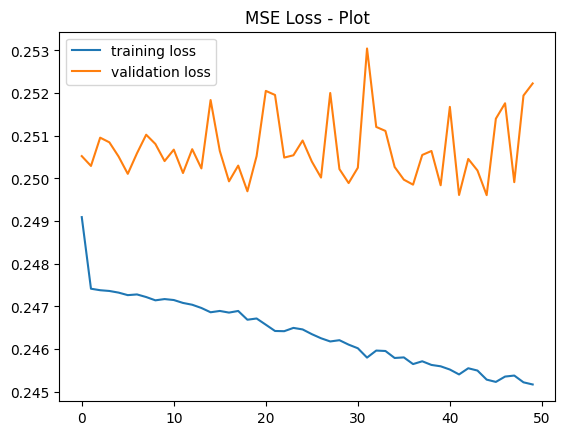

In [ ]:
import matplotlib.pyplot as plt

plt.title("MSE Loss - Plot")
plt.plot(history["train_loss"], label="training loss")
plt.plot(history["valid_loss"], label="validation loss")
plt.legend()

plt.show()

## Homework: n-grams with words

Try at home.

Until now, we use characters to create the n-grams, in a suboptimal way.

Let's try to use words instead. To do this you need a word splitter.

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
text = "Natural language processing (NLP) is a field of computer science, artificial intelligence and computational linguistics concerned with the interactions between computers and human (natural) languages, and, in particular, concerned with programming computers to fruitfully process large natural language corpora. Challenges in natural language processing frequently involve natural language understanding, natural language generation (frequently from formal, machine-readable logical forms), connecting language and machine perception, managing human-computer dialog systems, or some combination thereof."

print(sent_tokenize(text))
print(word_tokenize(text))


['Natural language processing (NLP) is a field of computer science, artificial intelligence and computational linguistics concerned with the interactions between computers and human (natural) languages, and, in particular, concerned with programming computers to fruitfully process large natural language corpora.', 'Challenges in natural language processing frequently involve natural language understanding, natural language generation (frequently from formal, machine-readable logical forms), connecting language and machine perception, managing human-computer dialog systems, or some combination thereof.']
['Natural', 'language', 'processing', '(', 'NLP', ')', 'is', 'a', 'field', 'of', 'computer', 'science', ',', 'artificial', 'intelligence', 'and', 'computational', 'linguistics', 'concerned', 'with', 'the', 'interactions', 'between', 'computers', 'and', 'human', '(', 'natural', ')', 'languages', ',', 'and', ',', 'in', 'particular', ',', 'concerned', 'with', 'programming', 'computers', 't

In [ ]:
# Example of dataset class

class SADatasetWG(Dataset):
    """An automatically generated dataset for our language classification task."""

    def _get_grams(self, sentence_list):
      grams = {}
      # for each sentence
      for s in sentence_list: # maybe limit
        # for each gram

        if len(list(grams.keys())) > self.vocab_max_len:
          return list(grams.keys())[:self.vocab_max_len]

      return list(grams.keys())

    def _get_gram_vector(self, sentence):
      sent_grams = self._get_grams([sentence])
      vector = []

      for gram in self.grams:
        # something like: vector.append(sent_grams.contains(bigram) ? 1.0 : 0.0)
        vector.append(1.0 if gram in sent_grams else 0.0)

      # vector = [1.0, 1.0, 0.0, 0.0]
      return vector

    def __init__(self, dataset, vocab_max_len = -1, training_grams = None):
        """
        Args:
            dataset: huggingface datset, with idx, sentence, label features
        """

        self.vocab_max_len = vocab_max_len

        self.num_samples = len(dataset)
        if not training_grams:
          self.grams = self._get_grams([x["sentence"] for x in dataset])
        else:
          self.grams = training_grams

        # training data is a list of dictionaries
        # each dictionary contains two keys: 'inputs' and 'outputs'
        self.data = []
        for sample in dataset:
            sentence = sample["sentence"].lower()
            item = {'inputs': torch.tensor(self._get_gram_vector(sentence)), 'outputs': torch.tensor([sample["label"]], dtype=torch.float)}
            self.data.append(item)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, i):
        return self.data[i]